# 02 - Construccion del dataset multibacteria V2 binario

Este notebook construye los datasets finales para clasificacion binaria:

- `Susceptible`
- `Resistant`

La clase `Intermediate` se excluye desde la construccion del dataset para obtener un planteamiento mas estable y claro.


## 1. Configuracion

In [1]:
from pathlib import Path
import gc
import csv
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
CHUNKSIZE = 250_000
CLASES_OBJETIVO = ["Susceptible", "Resistant"]
plt.style.use("seaborn-v0_8-whitegrid")

RUTA_ACTUAL = Path.cwd().resolve()
RUTA_MODELO = None
for candidata in [RUTA_ACTUAL, *RUTA_ACTUAL.parents]:
    if (candidata / "data" / "microbiology_cultures_cohort.csv").exists() and candidata.name.lower() == "modelo":
        RUTA_MODELO = candidata
        break
    if (candidata / "modelo" / "data" / "microbiology_cultures_cohort.csv").exists():
        RUTA_MODELO = candidata / "modelo"
        break
if RUTA_MODELO is None:
    raise FileNotFoundError("No se encontro modelo/data con los CSV crudos")

RUTA_DATA = RUTA_MODELO / "data"
RUTA_V2 = RUTA_MODELO / "V2"
RUTA_PROCESADOS = RUTA_V2 / "DATOS_PROCESADOS"
RUTA_GRAFICAS = RUTA_V2 / "GRAFICAS"
RUTA_PROCESADOS.mkdir(parents=True, exist_ok=True)
RUTA_GRAFICAS.mkdir(parents=True, exist_ok=True)

RUTAS = {
    "cohort": RUTA_DATA / "microbiology_cultures_cohort.csv",
    "demographics": RUTA_DATA / "microbiology_cultures_demographics.csv",
    "ward": RUTA_DATA / "microbiology_cultures_ward_info.csv",
    "adi": RUTA_DATA / "microbiology_cultures_adi_scores.csv",
    "vitals": RUTA_DATA / "microbiology_cultures_vitals.csv",
    "labs": RUTA_DATA / "microbiology_cultures_labs.csv",
    "abx_class": RUTA_DATA / "microbiology_cultures_antibiotic_class_exposure.csv",
    "comorb": RUTA_DATA / "microbiology_cultures_comorbidity.csv",
}

ORGANISMOS_V2 = pd.read_csv(RUTA_PROCESADOS / "03_decision_organismos_v2.csv")["organism"].tolist()
llaves = ["anon_id", "pat_enc_csn_id_coded", "order_proc_id_coded"]


def normalizar_llaves(df_local, llaves_locales):
    df_local = df_local.copy()
    for llave in llaves_locales:
        if llave in df_local.columns:
            df_local[llave] = df_local[llave].astype("string")
    return df_local


def merge_idempotente(df_base, df_nuevo, llaves_locales, how="left"):
    df_base = normalizar_llaves(df_base, llaves_locales)
    df_nuevo = normalizar_llaves(df_nuevo, llaves_locales)
    columnas_nuevas = [c for c in df_nuevo.columns if c not in llaves_locales]
    columnas_a_reemplazar = [c for c in columnas_nuevas if c in df_base.columns]
    if columnas_a_reemplazar:
        df_base = df_base.drop(columns=columnas_a_reemplazar)
    return df_base.merge(df_nuevo, on=llaves_locales, how=how)


def filtrar_por_ordenes_csv(ruta, columnas, ordenes, chunksize=CHUNKSIZE):
    partes = []
    for chunk in pd.read_csv(ruta, usecols=columnas, chunksize=chunksize, low_memory=False):
        chunk = normalizar_llaves(chunk, [c for c in llaves if c in chunk.columns])
        filtrado = chunk[chunk["order_proc_id_coded"].isin(ordenes)].copy()
        if not filtrado.empty:
            partes.append(filtrado)
    if not partes:
        return pd.DataFrame(columns=columnas)
    return pd.concat(partes, ignore_index=True)

print("Organismos V2:", ORGANISMOS_V2)
print("Clases objetivo:", CLASES_OBJETIVO)


Organismos V2: ['ESCHERICHIA COLI', 'KLEBSIELLA PNEUMONIAE', 'STAPHYLOCOCCUS AUREUS', 'PROTEUS MIRABILIS', 'ENTEROCOCCUS SPECIES', 'PSEUDOMONAS AERUGINOSA']
Clases objetivo: ['Susceptible', 'Resistant']


## 2. Cohorte principal binaria

In [2]:
columnas_cohort = [
    "anon_id", "pat_enc_csn_id_coded", "order_proc_id_coded", "order_time_jittered_utc",
    "ordering_mode", "culture_description", "organism", "antibiotic", "susceptibility"
]

partes = []
for chunk in pd.read_csv(RUTAS["cohort"], usecols=columnas_cohort, chunksize=CHUNKSIZE, low_memory=False):
    chunk["organism"] = chunk["organism"].astype("string").str.strip()
    chunk["susceptibility"] = chunk["susceptibility"].astype("string").str.strip()
    mask = chunk["organism"].isin(ORGANISMOS_V2) & chunk["susceptibility"].isin(CLASES_OBJETIVO)
    if mask.any():
        partes.append(chunk.loc[mask].copy())

df = pd.concat(partes, ignore_index=True)
del partes
gc.collect()

df = df.dropna(subset=["organism", "antibiotic", "culture_description", "susceptibility"])
df = normalizar_llaves(df, llaves)

print("Filas cohort V2 binaria:", f"{len(df):,}")
print("Ordenes unicas:", f"{df['order_proc_id_coded'].nunique():,}")
pd.crosstab(df["organism"], df["susceptibility"])


Filas cohort V2 binaria: 1,254,018
Ordenes unicas: 94,287


susceptibility,Resistant,Susceptible
organism,,
ENTEROCOCCUS SPECIES,12242,50524
ESCHERICHIA COLI,122595,729553
KLEBSIELLA PNEUMONIAE,20624,124462
PROTEUS MIRABILIS,11731,55065
PSEUDOMONAS AERUGINOSA,5460,40020
STAPHYLOCOCCUS AUREUS,17866,63876


## 3. Integracion de variables clinicas

In [3]:
df_demo = pd.read_csv(RUTAS["demographics"], usecols=llaves + ["age", "gender"], low_memory=False)
df = merge_idempotente(df, df_demo.drop_duplicates(subset=llaves), llaves)
del df_demo; gc.collect()

df_ward = pd.read_csv(RUTAS["ward"], usecols=llaves + ["hosp_ward_IP", "hosp_ward_OP", "hosp_ward_ER", "hosp_ward_ICU"], low_memory=False)
df = merge_idempotente(df, df_ward.drop_duplicates(subset=llaves), llaves)
del df_ward; gc.collect()

df_adi = pd.read_csv(RUTAS["adi"], usecols=llaves + ["adi_score", "adi_state_rank"], low_memory=False)
df = merge_idempotente(df, df_adi.drop_duplicates(subset=llaves), llaves)
del df_adi; gc.collect()

for col in ["hosp_ward_ICU", "hosp_ward_ER", "hosp_ward_IP", "hosp_ward_OP"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype("int8")

ordenes_v2 = set(df["order_proc_id_coded"].astype(str))

cols_vitals = llaves + ["median_temp", "median_heartrate", "median_resprate", "median_sysbp", "median_diasbp"]
df_vitals = filtrar_por_ordenes_csv(RUTAS["vitals"], cols_vitals, ordenes_v2).drop_duplicates(subset=llaves)
df = merge_idempotente(df, df_vitals, llaves)
del df_vitals; gc.collect()

cols_labs = llaves + ["median_wbc", "median_cr", "median_bun", "median_lactate", "median_procalcitonin", "median_neutrophils", "median_lymphocytes"]
df_labs = filtrar_por_ordenes_csv(RUTAS["labs"], cols_labs, ordenes_v2).drop_duplicates(subset=llaves)
df = merge_idempotente(df, df_labs, llaves)
del df_labs; gc.collect()

cols_numericas_clinicas = [
    "adi_score", "adi_state_rank", "median_temp", "median_heartrate", "median_resprate", "median_sysbp", "median_diasbp",
    "median_wbc", "median_cr", "median_bun", "median_lactate", "median_procalcitonin", "median_neutrophils", "median_lymphocytes",
]
for col in cols_numericas_clinicas:
    if col in df.columns:
        df[f"missing_{col}"] = df[col].isna().astype("int8")
        df[col] = pd.to_numeric(df[col], errors="coerce")

print(df.shape)


(1254018, 43)


## 4. Exposicion antibiotica previa y comorbilidades

In [4]:
def nombre_seguro(texto):
    texto = str(texto).strip().lower()
    for origen, destino in {"/": "_", "-": "_", " ": "_", "(": "", ")": "", ",": "", "+": "_"}.items():
        texto = texto.replace(origen, destino)
    while "__" in texto:
        texto = texto.replace("__", "_")
    return texto.strip("_")

cols_abx = ["order_proc_id_coded", "antibiotic_class"]
df_abx = filtrar_por_ordenes_csv(RUTAS["abx_class"], cols_abx, ordenes_v2)
df_abx = df_abx.dropna(subset=["antibiotic_class"])
df_abx["antibiotic_class"] = df_abx["antibiotic_class"].astype(str).str.strip()
df_abx = df_abx[df_abx["antibiotic_class"].ne("")]
if not df_abx.empty:
    df_abx["columna"] = "exp_prev_" + df_abx["antibiotic_class"].map(nombre_seguro)
    df_abx["valor"] = 1
    df_abx_multi = df_abx.pivot_table(index="order_proc_id_coded", columns="columna", values="valor", aggfunc="max", fill_value=0).reset_index()
else:
    df_abx_multi = pd.DataFrame({"order_proc_id_coded": list(ordenes_v2)})

df_abx_multi = normalizar_llaves(df_abx_multi, ["order_proc_id_coded"])
df = merge_idempotente(df, df_abx_multi, ["order_proc_id_coded"])
cols_exp = [c for c in df.columns if c.startswith("exp_prev_")]
df[cols_exp] = df[cols_exp].fillna(0).astype("int8")
pd.DataFrame({"variable": cols_exp}).to_csv(RUTA_PROCESADOS / "04_catalogo_exp_prev_v2.csv", index=False)

MAPA_COMORB = {
    "Congestive heart failure": "comorb_congestive_heart_failure",
    "Organ transplant status": "comorb_organ_transplant_status",
    "Diabetes mellitus without complication": "comorb_diabetes_any",
    "Diabetes mellitus with complications": "comorb_diabetes_any",
    "Solid tumor without metastasis": "comorb_solid_tumor_non_metastatic",
    "Chronic pulmonary disease": "comorb_chronic_pulmonary_any",
    "Renal failure": "comorb_renal_failure",
    "Pancreatic disease": "comorb_pancreatic_disorder",
    "Sinusitis": "comorb_sinusitis",
}
valores_comorb = defaultdict(set)
componentes_interes = set(MAPA_COMORB)
with RUTAS["comorb"].open("r", encoding="utf-8", newline="") as archivo:
    lector = csv.DictReader(archivo)
    for fila in lector:
        orden = str(fila.get("order_proc_id_coded") or "")
        if orden not in ordenes_v2:
            continue
        componente = (fila.get("comorbidity_component") or "").strip()
        if componente in componentes_interes:
            valores_comorb[orden].add(MAPA_COMORB[componente])

filas_comorb = []
for orden, grupos in valores_comorb.items():
    fila = {"order_proc_id_coded": orden}
    for grupo in grupos:
        fila[grupo] = 1
    filas_comorb.append(fila)

df_comorb = pd.DataFrame(filas_comorb)
if df_comorb.empty:
    df_comorb = pd.DataFrame({"order_proc_id_coded": list(ordenes_v2)})
cols_comorb = sorted(set(MAPA_COMORB.values()))
for col in cols_comorb:
    if col not in df_comorb.columns:
        df_comorb[col] = 0
    df_comorb[col] = df_comorb[col].fillna(0).astype("int8")
df_comorb = normalizar_llaves(df_comorb, ["order_proc_id_coded"])
df = merge_idempotente(df, df_comorb[["order_proc_id_coded"] + cols_comorb], ["order_proc_id_coded"])
df[cols_comorb] = df[cols_comorb].fillna(0).astype("int8")
pd.DataFrame({"variable": cols_comorb}).to_csv(RUTA_PROCESADOS / "05_catalogo_comorb_v2.csv", index=False)

print("exp_prev:", len(cols_exp), "comorb:", len(cols_comorb), "shape:", df.shape)


exp_prev: 18 comorb: 8 shape: (1254018, 69)


## 5. Limpieza final

In [5]:
columnas_categoricas = ["organism", "antibiotic", "culture_description", "ordering_mode", "age", "gender"]
for col in columnas_categoricas:
    df[col] = df[col].astype("string").fillna("SIN_REGISTRO").str.strip()
    df.loc[df[col].eq(""), col] = "SIN_REGISTRO"

antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print("Duplicados exactos removidos:", antes - len(df))

# Seguridad: no deben quedar columnas duplicadas por merges reejecutados.
cols_sospechosas = [c for c in df.columns if c.endswith("_x") or c.endswith("_y")]
if cols_sospechosas:
    raise ValueError(f"Columnas duplicadas detectadas por merge: {cols_sospechosas[:10]}")

resumen_final = pd.DataFrame({
    "metrica": ["filas", "ordenes_unicas", "organismos", "antibioticos", "columnas"],
    "valor": [len(df), df["order_proc_id_coded"].nunique(), df["organism"].nunique(), df["antibiotic"].nunique(), df.shape[1]],
})
resumen_final.to_csv(RUTA_PROCESADOS / "06_resumen_dataset_v2_completo.csv", index=False)
resumen_final


Duplicados exactos removidos: 0


,metrica,valor
0,filas,1254018
1,ordenes_unicas,94287
2,organismos,6
3,antibioticos,51
4,columnas,69


## 6. Datasets completo y balanceados

Se crean tres versiones:

- completo binario
- balanceado por clase
- balanceado por organismo y clase

La version recomendada para modelado es `09_dataset_v2_multibacteria_balanceado_organismo_clase.csv`.


In [6]:
RUTA_COMPLETO = RUTA_PROCESADOS / "07_dataset_v2_multibacteria_completo.csv"
RUTA_BAL_CLASE = RUTA_PROCESADOS / "08_dataset_v2_multibacteria_balanceado_clase.csv"
RUTA_BAL_ORG_CLASE = RUTA_PROCESADOS / "09_dataset_v2_multibacteria_balanceado_organismo_clase.csv"

# 1) Balanceado por clase global: baja Susceptible al tamano de Resistant.
conteo_clases = df["susceptibility"].value_counts()
n_por_clase = int(conteo_clases.min())
df_bal_clase = pd.concat([
    grupo.sample(n_por_clase, random_state=RANDOM_STATE) if len(grupo) > n_por_clase else grupo
    for _, grupo in df.groupby("susceptibility")
], ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# 2) Balanceado por organismo y clase: controla tanto bacteria como target.
MIN_GRUPO = 500
MAX_POR_ORG_CLASE = 25_000
partes = []
for (organismo, clase), grupo in df.groupby(["organism", "susceptibility"], sort=False):
    n = min(len(grupo), MAX_POR_ORG_CLASE)
    if n < MIN_GRUPO:
        partes.append(grupo)
    else:
        partes.append(grupo.sample(n, random_state=RANDOM_STATE))
df_bal_org_clase = pd.concat(partes, ignore_index=True).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

df.to_csv(RUTA_COMPLETO, index=False)
df_bal_clase.to_csv(RUTA_BAL_CLASE, index=False)
df_bal_org_clase.to_csv(RUTA_BAL_ORG_CLASE, index=False)

resumenes = []
for nombre, datos in [("completo", df), ("balanceado_clase", df_bal_clase), ("balanceado_organismo_clase", df_bal_org_clase)]:
    dist = datos["susceptibility"].value_counts().rename_axis("susceptibility").reset_index(name="filas")
    dist["dataset"] = nombre
    dist["porcentaje"] = dist["filas"] / len(datos) * 100
    resumenes.append(dist)
resumen_balance = pd.concat(resumenes, ignore_index=True)
resumen_balance.to_csv(RUTA_PROCESADOS / "10_resumen_balance_clases_v2.csv", index=False)

pd.crosstab(df_bal_org_clase["organism"], df_bal_org_clase["susceptibility"]).to_csv(RUTA_PROCESADOS / "11_balance_organismo_clase_v2.csv")

print("Completo:", df.shape)
print("Balanceado clase:", df_bal_clase.shape)
print("Balanceado organismo/clase:", df_bal_org_clase.shape)
resumen_balance


Completo: (1254018, 69)
Balanceado clase: (381036, 69)
Balanceado organismo/clase: (242923, 69)


,susceptibility,filas,dataset,porcentaje
0,Susceptible,1063500,completo,84.807395
1,Resistant,190518,completo,15.192605
2,Resistant,190518,balanceado_clase,50.0
3,Susceptible,190518,balanceado_clase,50.0
4,Susceptible,150000,balanceado_organismo_clase,61.747961
5,Resistant,92923,balanceado_organismo_clase,38.252039


## 7. Imagenes post-preprocesamiento

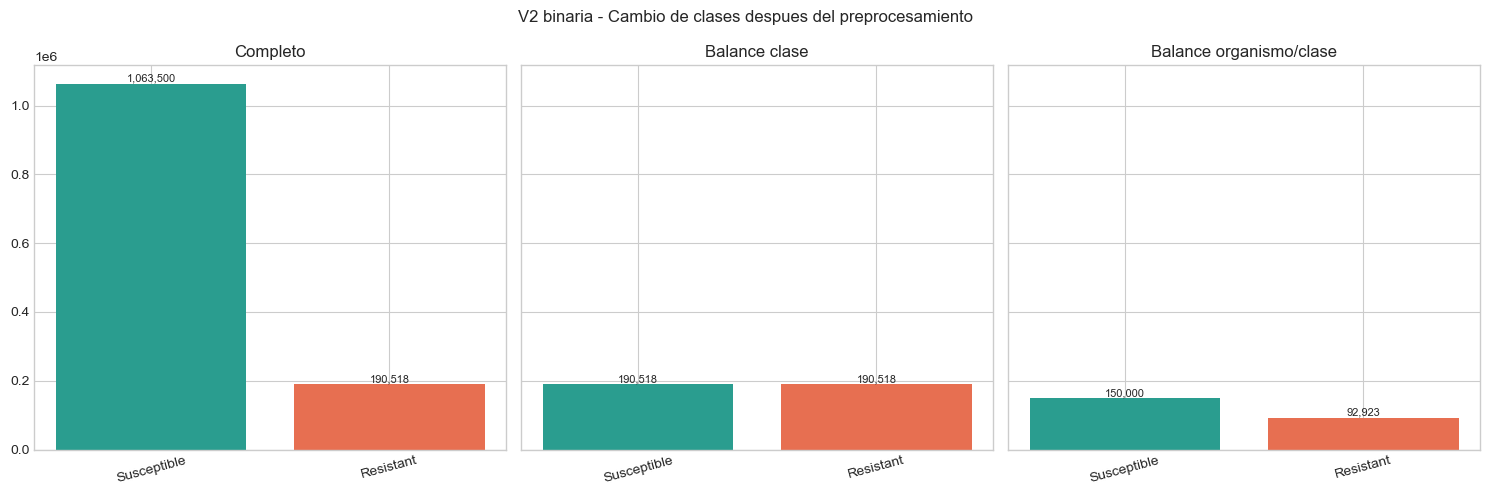

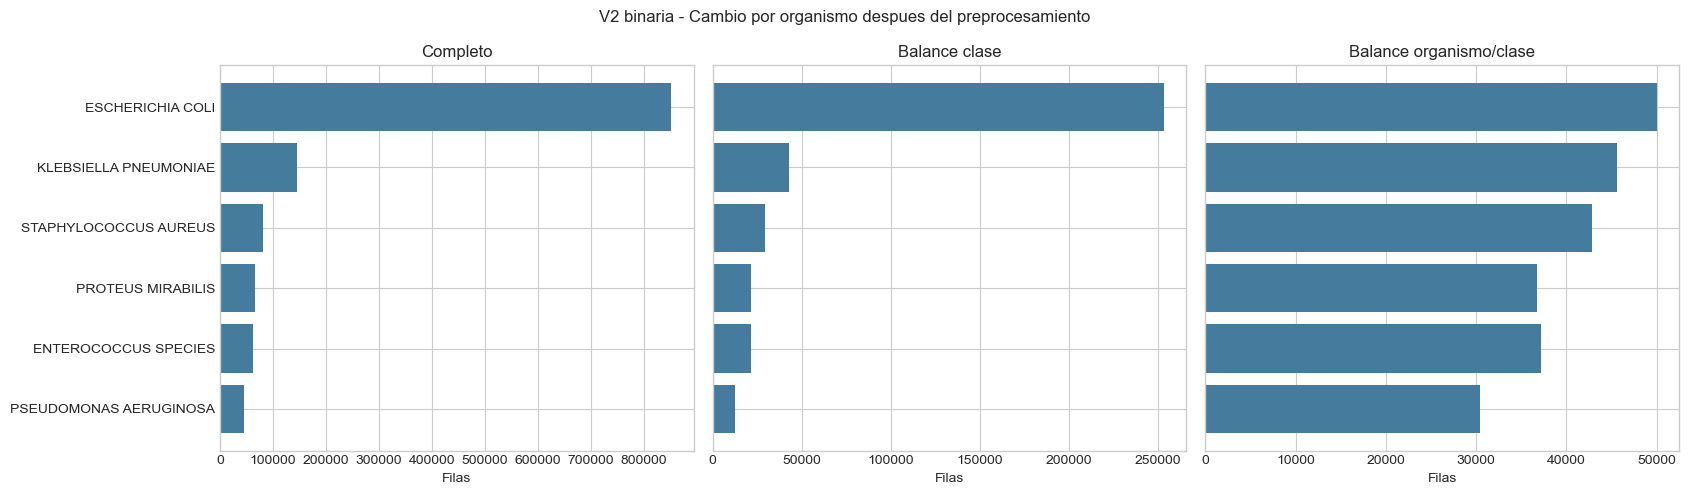

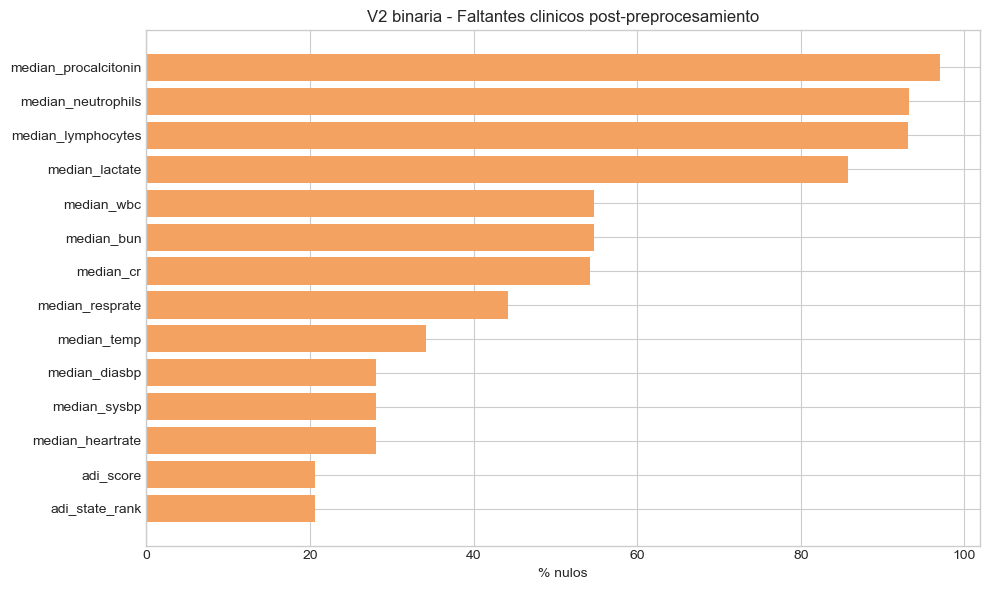

,variable,porcentaje_nulos
0,median_procalcitonin,97.047212
1,median_neutrophils,93.162854
2,median_lymphocytes,93.060352
3,median_lactate,85.716462
4,median_wbc,54.741626
5,median_bun,54.698814
6,median_cr,54.243114
7,median_resprate,44.207012
8,median_temp,34.158561
9,median_diasbp,28.135253


In [7]:
def guardar_figura(fig, nombre):
    fig.tight_layout()
    fig.savefig(RUTA_GRAFICAS / nombre, dpi=220, bbox_inches="tight")
    plt.show()

orden_clases = ["Susceptible", "Resistant"]
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, datos, titulo in [(axes[0], df, "Completo"), (axes[1], df_bal_clase, "Balance clase"), (axes[2], df_bal_org_clase, "Balance organismo/clase")]:
    conteo = datos["susceptibility"].value_counts().reindex(orden_clases).fillna(0)
    ax.bar(conteo.index, conteo.values, color=["#2a9d8f", "#e76f51"])
    ax.set_title(titulo)
    ax.tick_params(axis="x", rotation=15)
    for i, valor in enumerate(conteo.values):
        ax.text(i, valor, f"{int(valor):,}", ha="center", va="bottom", fontsize=8)
fig.suptitle("V2 binaria - Cambio de clases despues del preprocesamiento")
guardar_figura(fig, "07_v2_binario_preprocesamiento_cambio_susceptibility.png")

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
for ax, datos, titulo in [(axes[0], df, "Completo"), (axes[1], df_bal_clase, "Balance clase"), (axes[2], df_bal_org_clase, "Balance organismo/clase")]:
    conteo = datos["organism"].value_counts().sort_values()
    ax.barh(conteo.index, conteo.values, color="#457b9d")
    ax.set_title(titulo)
    ax.set_xlabel("Filas")
fig.suptitle("V2 binaria - Cambio por organismo despues del preprocesamiento")
guardar_figura(fig, "08_v2_binario_preprocesamiento_cambio_organismos.png")

cols_clinicas = [c for c in df_bal_org_clase.columns if c.startswith("median_") or c in ["adi_score", "adi_state_rank"]]
faltantes = (df_bal_org_clase[cols_clinicas].isna().mean() * 100).sort_values(ascending=False).reset_index()
faltantes.columns = ["variable", "porcentaje_nulos"]
faltantes.to_csv(RUTA_PROCESADOS / "12_faltantes_clinicos_v2_post_preprocesamiento.csv", index=False)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(faltantes["variable"], faltantes["porcentaje_nulos"], color="#f4a261")
ax.invert_yaxis()
ax.set_title("V2 binaria - Faltantes clinicos post-preprocesamiento")
ax.set_xlabel("% nulos")
guardar_figura(fig, "09_v2_binario_preprocesamiento_faltantes_clinicos.png")
faltantes


## 8. Conclusion

El dataset recomendado para entrenamiento es:

- `09_dataset_v2_multibacteria_balanceado_organismo_clase.csv`

Esta version excluye `Intermediate`, conserva las 6 bacterias y controla mejor el desbalance por organismo y clase.
